# Notebook 03: Fitting Transmission Spectra

This notebook demonstrates the Levenberg-Marquardt fitting engine: given a measured transmission spectrum, recover the areal density of each isotope.

## Approach

1. Generate synthetic "measured" data using `forward_model()` with a known density
2. Add Gaussian noise to simulate experimental uncertainty
3. Fit with `fit_spectrum()` to recover the density
4. Analyze fit quality: residuals, chi-squared, uncertainty estimates

**Important**: `fit_spectrum()` does NOT apply resolution broadening (hardcoded `instrument=None`). To avoid systematic bias, we generate synthetic data without resolution broadening as well.

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)  # reproducibility

In [2]:
# U-238 resonance data
u238 = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
)

# Energy grid: fine spacing around the resonance
E_core = np.linspace(6.674 - 0.5, 6.674 + 0.5, 500)
E_wings_low = np.linspace(1.0, 6.674 - 0.5, 100)[:-1]
E_wings_high = np.linspace(6.674 + 0.5, 15.0, 100)[1:]
energies = np.sort(np.concatenate([E_wings_low, E_core, E_wings_high]))

print(f"Energy grid: {len(energies)} points")

Energy grid: 698 points


## 1. Generate Synthetic Measurement

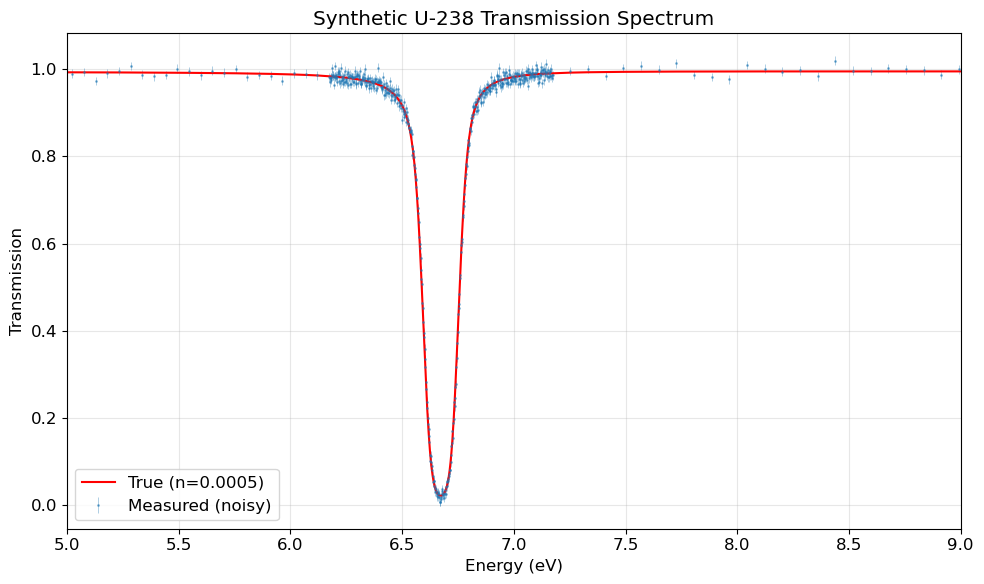

In [3]:
# True parameters
true_density = 5e-4  # atoms/barn
temperature = 300.0  # K
noise_level = 0.01   # Gaussian sigma on transmission

# Generate true transmission (no resolution broadening — matches fit model)
T_true = np.asarray(nereids.forward_model(
    energies, [(u238, true_density)], temperature_k=temperature
))

# Add Gaussian noise
noise = np.random.normal(0, noise_level, len(energies))
T_measured = T_true + noise
sigma = np.full_like(T_measured, noise_level)

fig, ax = plt.subplots()
ax.errorbar(energies, T_measured, yerr=sigma, fmt='.', markersize=2,
            alpha=0.5, label='Measured (noisy)', elinewidth=0.5)
ax.plot(energies, T_true, 'r-', linewidth=1.5, label=f'True (n={true_density})')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('Synthetic U-238 Transmission Spectrum')
ax.legend()
ax.set_xlim(5, 9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Fit the Spectrum

In [4]:
result = nereids.fit_spectrum(
    T_measured, sigma, energies,
    [u238],
    temperature_k=temperature,
    initial_densities=[1e-3],  # initial guess
    max_iter=100
)

print(result)
print()
fitted_density = result.densities[0]
fitted_unc = result.uncertainties[0]
rel_error = abs(fitted_density - true_density) / true_density * 100

print(f"True density:    {true_density:.6f} atoms/barn")
print(f"Fitted density:  {fitted_density:.6f} ± {fitted_unc:.6f} atoms/barn")
print(f"Relative error:  {rel_error:.2f}%")
print(f"Reduced χ²:      {result.reduced_chi_squared:.4f}")
print(f"Converged:       {result.converged}")
print(f"Iterations:      {result.iterations}")

assert result.converged, "Fit did not converge!"
assert rel_error < 5, f"Relative error {rel_error:.1f}% exceeds 5% threshold"
print("\nFit quality check passed!")

FitResult(converged=true, chi2_red=0.9707, densities=[0.0004978478706458708])

True density:    0.000500 atoms/barn
Fitted density:  0.000498 ± 0.000002 atoms/barn
Relative error:  0.43%
Reduced χ²:      0.9707
Converged:       True
Iterations:      13

Fit quality check passed!


## 3. Fit Result Visualization

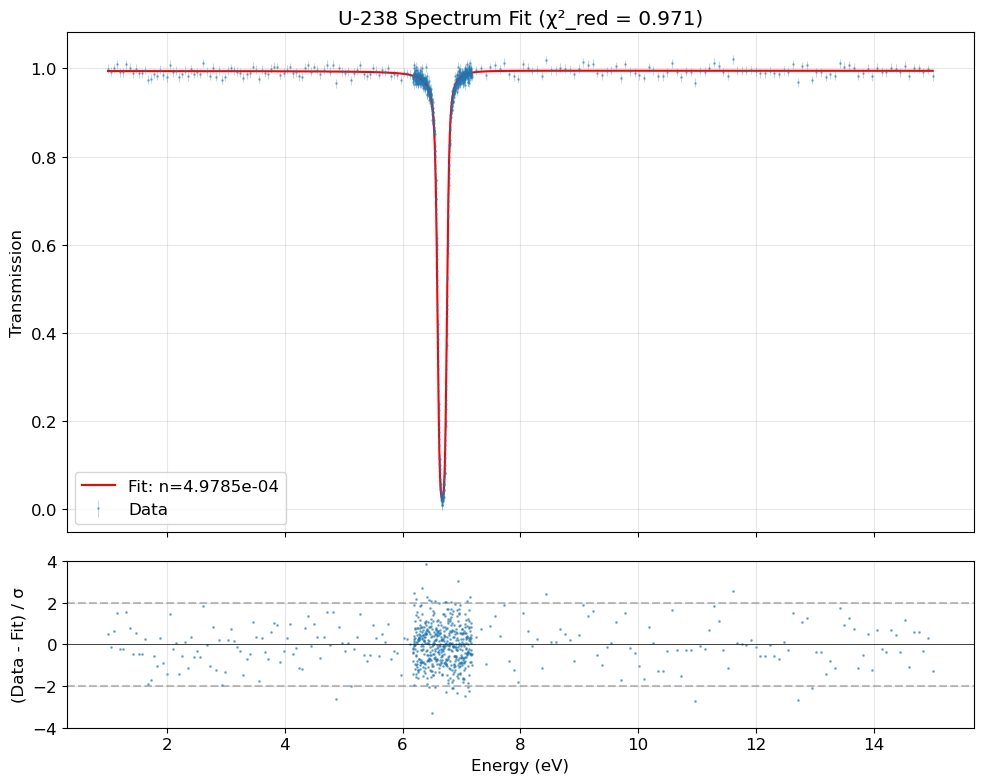

In [5]:
# Compute the fitted model
T_fitted = np.asarray(nereids.forward_model(
    energies, [(u238, fitted_density)], temperature_k=temperature
))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Top: data + fit
ax = axes[0]
ax.errorbar(energies, T_measured, yerr=sigma, fmt='.', markersize=2,
            alpha=0.4, label='Data', elinewidth=0.5, color='C0')
ax.plot(energies, T_fitted, 'r-', linewidth=1.5,
        label=f'Fit: n={fitted_density:.4e}')
ax.set_ylabel('Transmission')
ax.set_title(f'U-238 Spectrum Fit (χ²_red = {result.reduced_chi_squared:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom: standardized residuals
ax = axes[1]
residuals = (T_measured - T_fitted) / sigma
ax.scatter(energies, residuals, s=1, alpha=0.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(2, color='gray', linestyle='--', alpha=0.5)
ax.axhline(-2, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('(Data - Fit) / σ')
ax.set_ylim(-4, 4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

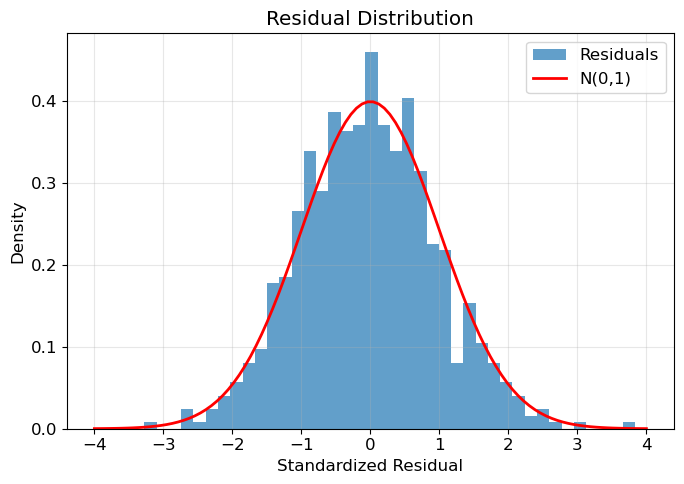

Residual mean: -0.0366 (expected: 0)
Residual std:  0.9838 (expected: 1)


In [6]:
# Residual distribution: should be approximately N(0,1)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(residuals, bins=40, density=True, alpha=0.7, label='Residuals')

# Overlay standard normal
x = np.linspace(-4, 4, 100)
ax.plot(x, np.exp(-x**2/2) / np.sqrt(2*np.pi), 'r-', linewidth=2, label='N(0,1)')

ax.set_xlabel('Standardized Residual')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Residual mean: {np.mean(residuals):.4f} (expected: 0)")
print(f"Residual std:  {np.std(residuals):.4f} (expected: 1)")

## 4. Initial Guess Sensitivity

A good optimizer should converge from a wide range of starting points.

In [7]:
initial_guesses = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

print(f"{'Initial Guess':>14} {'Fitted':>12} {'Rel Error':>10} {'χ²_red':>8} {'Iter':>6} {'Conv':>6}")
print("-" * 60)

for guess in initial_guesses:
    r = nereids.fit_spectrum(
        T_measured, sigma, energies, [u238],
        temperature_k=temperature,
        initial_densities=[guess],
        max_iter=200
    )
    rel_err = abs(r.densities[0] - true_density) / true_density * 100
    print(f"{guess:>14.1e} {r.densities[0]:>12.6f} {rel_err:>9.2f}% {r.reduced_chi_squared:>8.4f} {r.iterations:>6} {str(r.converged):>6}")

 Initial Guess       Fitted  Rel Error   χ²_red   Iter   Conv
------------------------------------------------------------
       1.0e-05     0.000498      0.43%   0.9707     13   True
       5.0e-05     0.000498      0.43%   0.9707      6   True
       1.0e-04     0.000498      0.43%   0.9707      6   True
       5.0e-04     0.000498      0.43%   0.9707      2   True
       1.0e-03     0.000498      0.43%   0.9707     13   True
       5.0e-03     0.000498      0.43%   0.9707     17   True
       1.0e-02     0.000498      0.43%   0.9707      7   True


## 5. Effect of Noise Level on Uncertainty

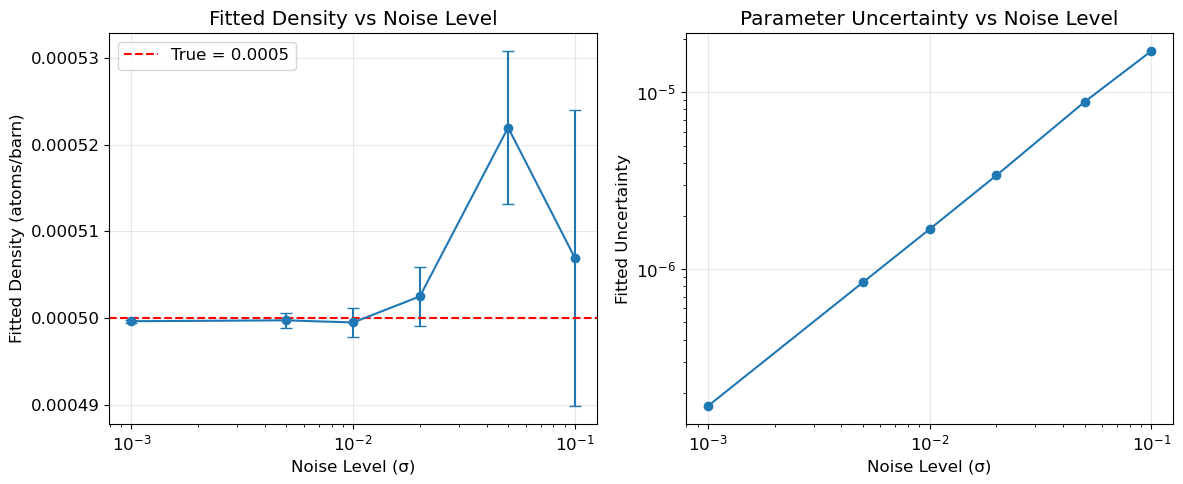

In [8]:
noise_levels = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
fitted_densities = []
fitted_uncertainties = []

for sigma_noise in noise_levels:
    noise = np.random.normal(0, sigma_noise, len(energies))
    T_noisy = T_true + noise
    s = np.full_like(T_noisy, sigma_noise)

    r = nereids.fit_spectrum(
        T_noisy, s, energies, [u238],
        temperature_k=temperature,
        initial_densities=[1e-3],
        max_iter=200
    )
    fitted_densities.append(r.densities[0])
    fitted_uncertainties.append(r.uncertainties[0])

fitted_densities = np.array(fitted_densities)
fitted_uncertainties = np.array(fitted_uncertainties)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: fitted density vs noise level
ax = axes[0]
ax.errorbar(noise_levels, fitted_densities, yerr=fitted_uncertainties,
            fmt='o-', capsize=4)
ax.axhline(true_density, color='r', linestyle='--', label=f'True = {true_density}')
ax.set_xlabel('Noise Level (σ)')
ax.set_ylabel('Fitted Density (atoms/barn)')
ax.set_title('Fitted Density vs Noise Level')
ax.legend()
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Right: uncertainty vs noise level
ax = axes[1]
ax.loglog(noise_levels, fitted_uncertainties, 'o-')
ax.set_xlabel('Noise Level (σ)')
ax.set_ylabel('Fitted Uncertainty')
ax.set_title('Parameter Uncertainty vs Noise Level')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Wrong Model Test

When the model is mis-specified (e.g., wrong temperature), the fit should show χ² >> 1.

In [9]:
# Data was generated at 300K. Fit with different temperatures.
test_temps = [0, 100, 200, 300, 500, 1000]

print(f"{'Fit Temp (K)':>12} {'Density':>12} {'χ²_red':>10} {'Conv':>6}")
print("-" * 44)

for T_fit in test_temps:
    r = nereids.fit_spectrum(
        T_measured, sigma, energies, [u238],
        temperature_k=float(T_fit),
        initial_densities=[1e-3],
        max_iter=200
    )
    marker = " ← correct" if T_fit == 300 else ""
    print(f"{T_fit:>12} {r.densities[0]:>12.6f} {r.reduced_chi_squared:>10.4f} {str(r.converged):>6}{marker}")

print("\nNote: χ²_red ≈ 1.0 only when the model temperature matches the data.")

Fit Temp (K)      Density     χ²_red   Conv
--------------------------------------------
           0     0.001137    16.5620   True
         100     0.000860     7.0989   True
         200     0.000627     2.5055   True
         300     0.000498     0.9707   True ← correct
         500     0.000402     7.3867   True
        1000     0.000349    50.5685  False

Note: χ²_red ≈ 1.0 only when the model temperature matches the data.


## Summary

In this notebook we demonstrated:

1. **Synthetic data generation**: `forward_model()` + Gaussian noise
2. **Levenberg-Marquardt fitting**: `fit_spectrum()` recovers the true areal density
3. **Fit quality**: residuals are N(0,1), reduced χ² ≈ 1.0
4. **Initial guess robustness**: convergence from a wide range of starting points
5. **Noise scaling**: uncertainty scales linearly with noise level
6. **Model mis-specification**: wrong temperature gives χ² >> 1

### Key Limitation

`fit_spectrum()` does not support resolution broadening — the internal model uses `instrument=None`. If fitting data that includes resolution effects, the fitted density will be biased. This is a known limitation that should be addressed in a future release.

**Next**: [04_multi_isotope_fitting.ipynb](04_multi_isotope_fitting.ipynb) — fitting multiple isotopes simultaneously.